Heart Disease Prediction Using Various Machine Learning Techniques.

We would be working with the heart disease prediction data that is found in UCI repository. Below is an actual link of the data that we would be working. We would be exploring various machine learning techniques that could be used for predictions and gain a good understanding of them by taking into consideration some of the important metrics such as accuracy, precision and recall. There are other metrics that are also present and are important that we would be exploring and which could be seen at the end of the project.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

Reading the data

In [2]:
data = pd.read_csv(r"C:\Users\rahul\INTERNSHIP\DATASETS\heart.csv")

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
if 'sex' in data.columns:
    label_encoder = LabelEncoder()
    data['sex'] = label_encoder.fit_transform(data['sex'])


Getting the information

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Understanding how the data is spread

In [7]:
data.describe().T      

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Countplot for output variable 'Target'

<Axes: xlabel='target', ylabel='count'>

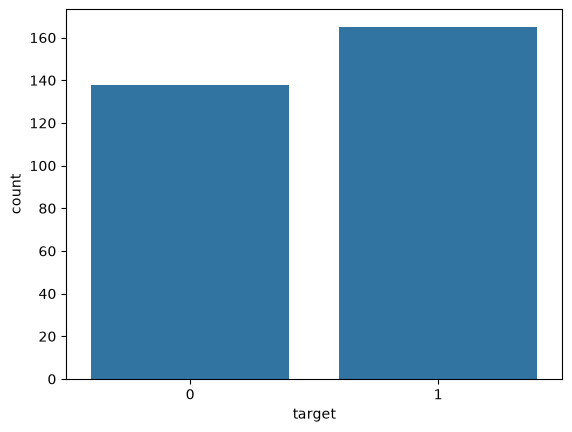

In [8]:
sns.countplot(data = data, x = 'target')

<Axes: xlabel='sex', ylabel='count'>

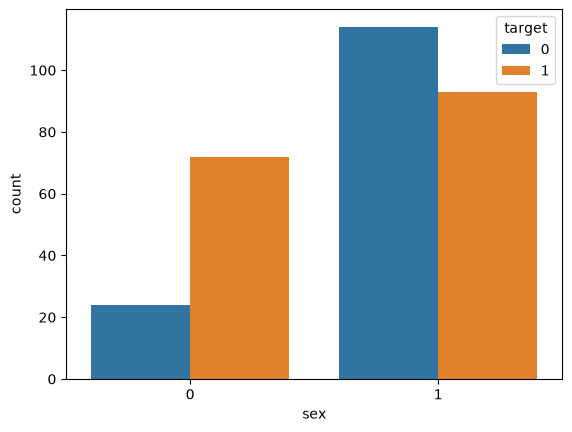

In [9]:

sns.countplot(data = data, x = 'sex', hue = 'target')

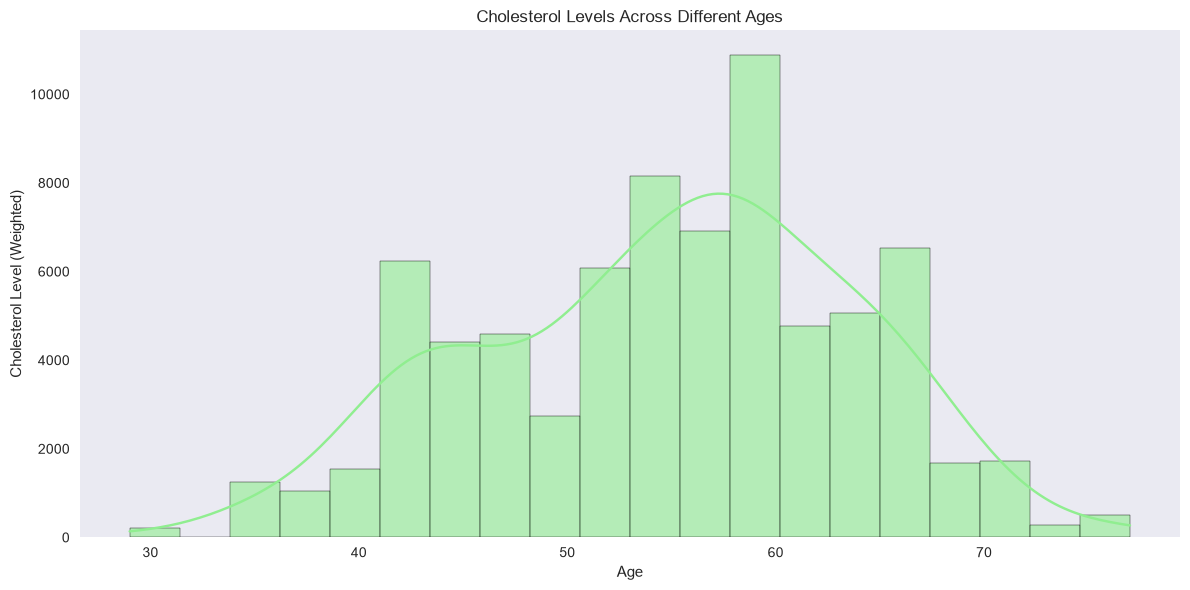

In [12]:
# Set up the plot style
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 6))

# Create a histogram of cholesterol levels with age on the x-axis
sns.histplot(data=data, x='age', weights='chol', bins=20, kde=True, color='lightgreen', alpha=0.6)

# Customize the plot
plt.title('Cholesterol Levels Across Different Ages')
plt.xlabel('Age')
plt.ylabel('Cholesterol Level (Weighted)')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()

Heatmap to understand correlation

<Axes: >

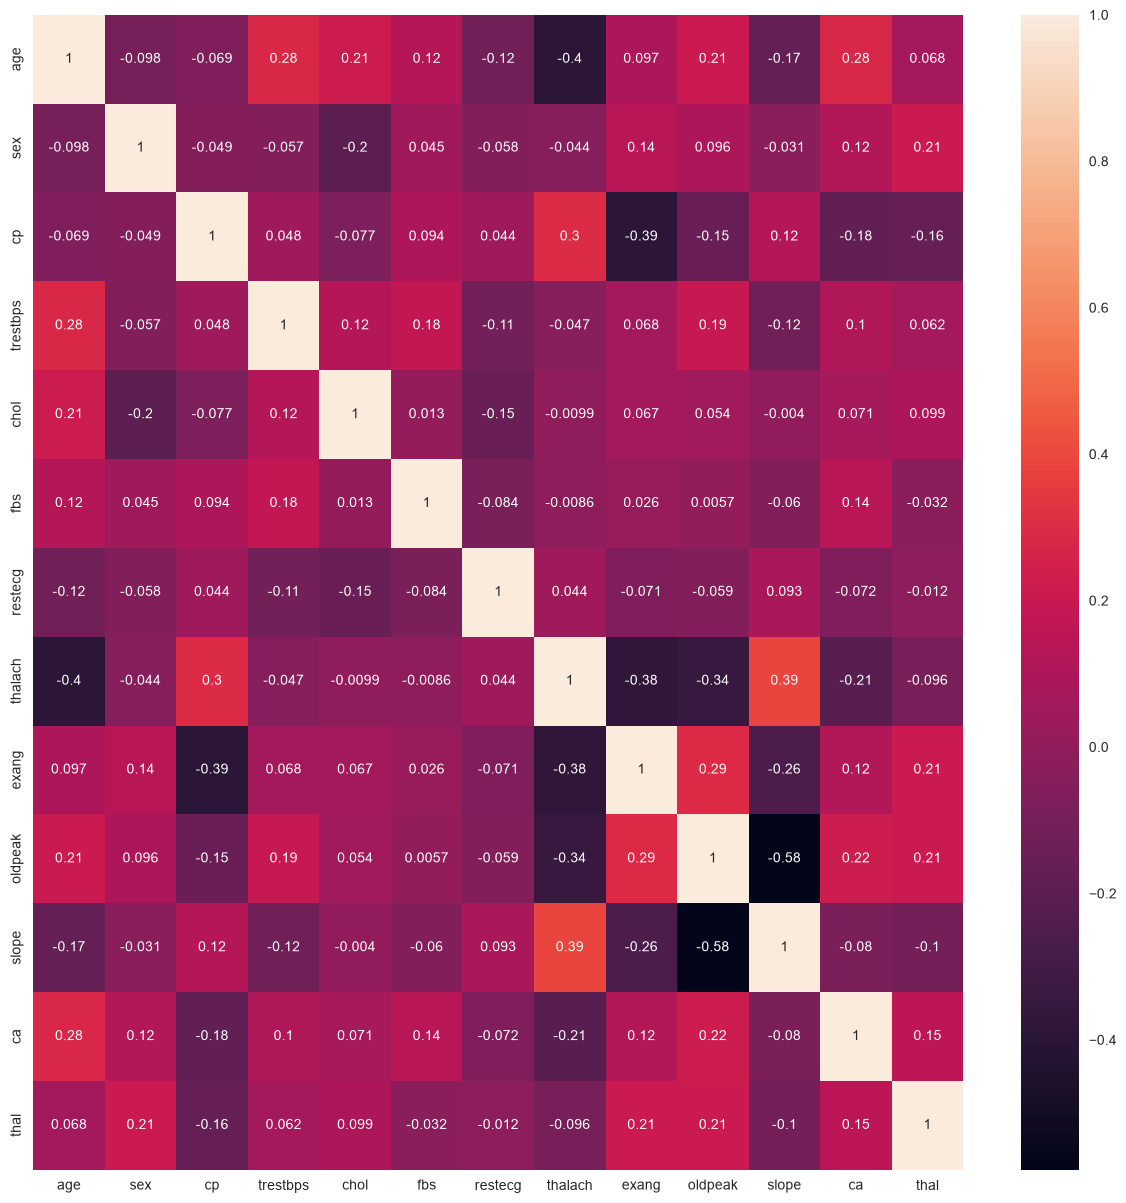

In [13]:
plt.figure(figsize = (15, 15))
sns.heatmap(data.drop(['target'], axis = 1).corr(), annot = True)


Regression plot for features

<Axes: xlabel='age', ylabel='thalach'>

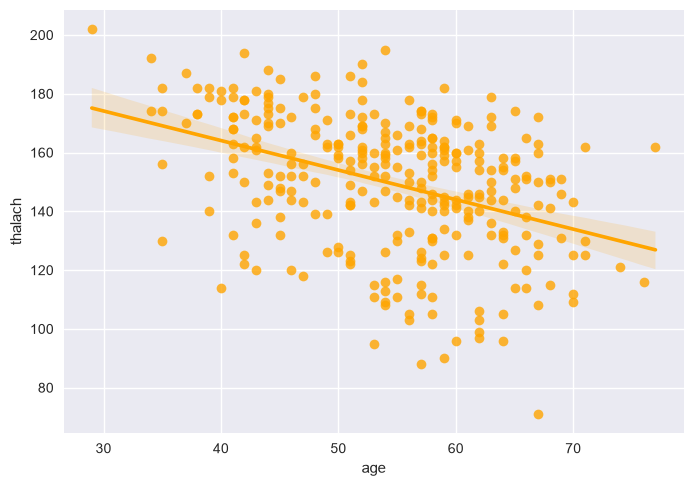

In [14]:
sns.regplot(x = 'age', y ='thalach', data = data, color = 'orange')

In [15]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Pairplot for the data points

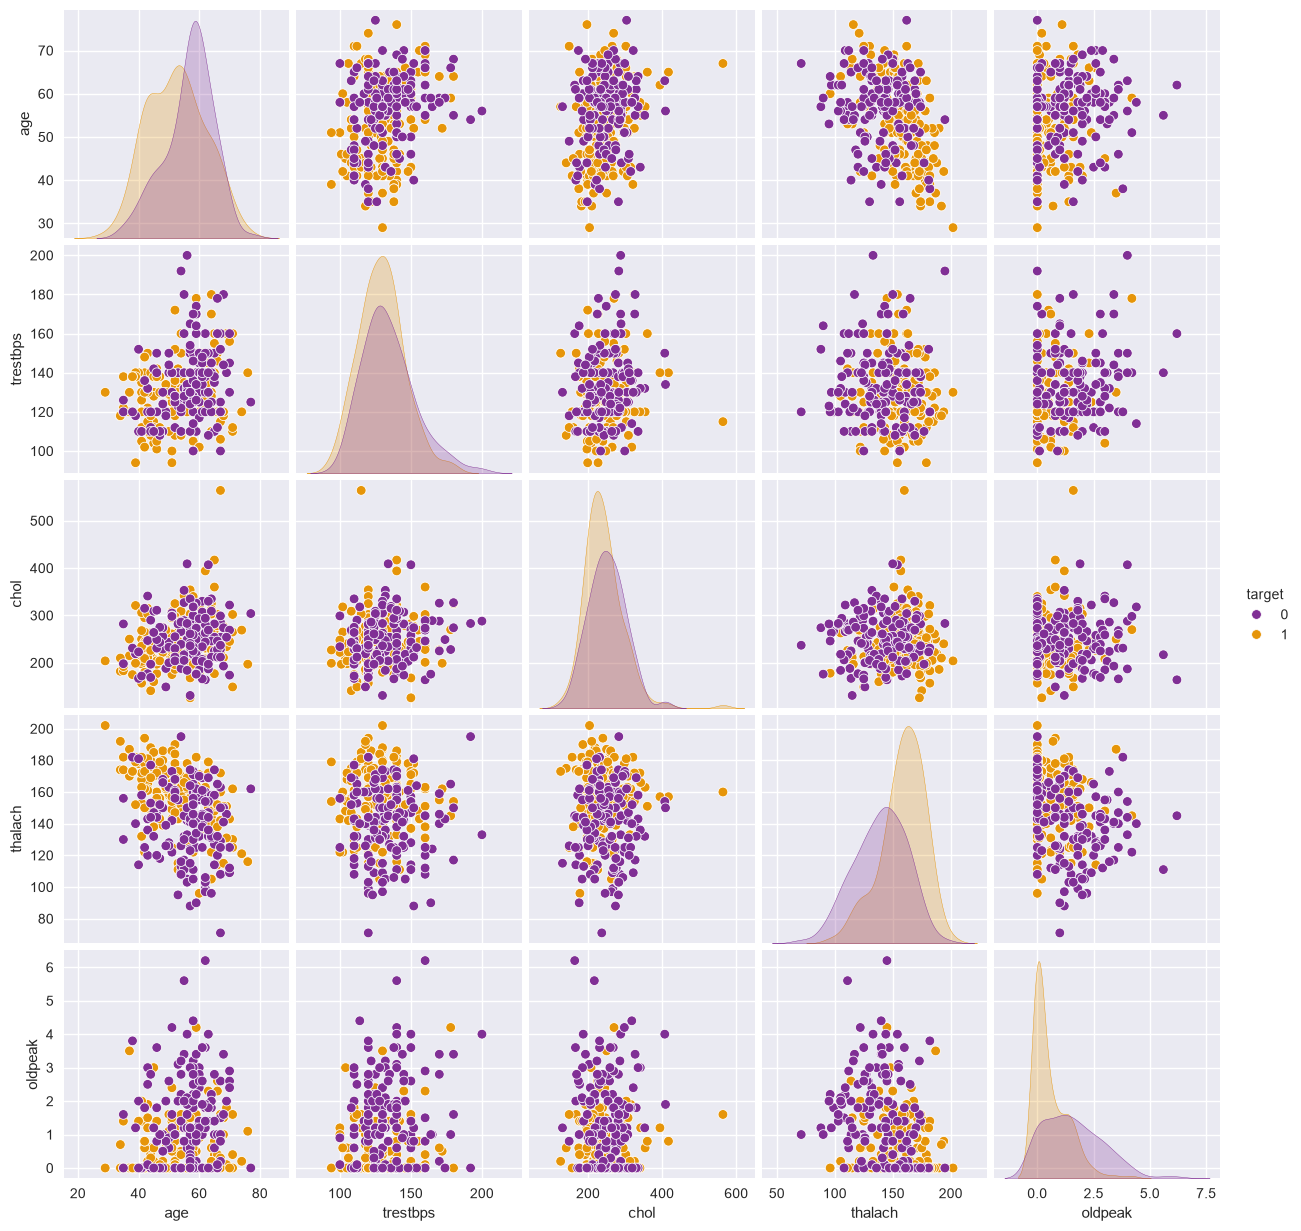

In [16]:
sns.pairplot(data[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']], hue = 'target', palette = 'CMRmap')


Regression plot for features

<Axes: xlabel='age', ylabel='chol'>

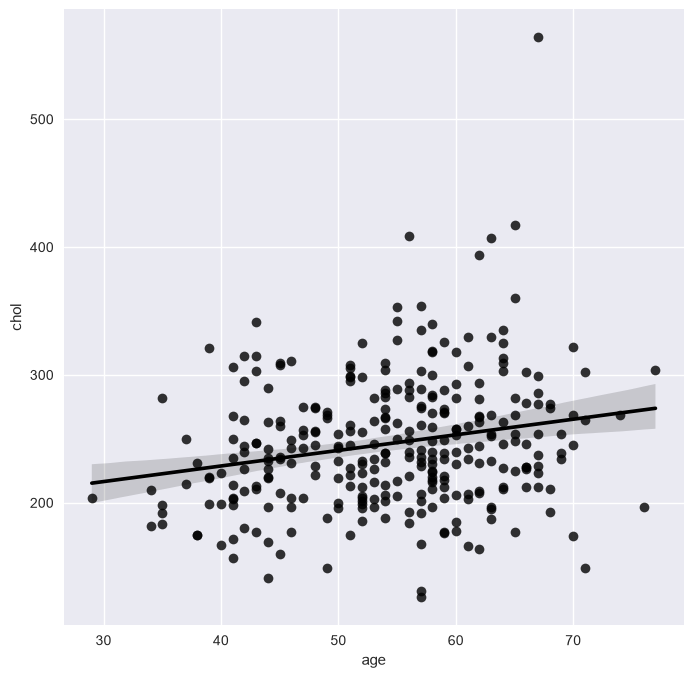

In [17]:
plt.figure(figsize = (8, 8))
sns.regplot(data = data, x = 'age', y = 'chol', color = 'black')


Boxplot for feature 'Cholestrol'

<Axes: xlabel='chol'>

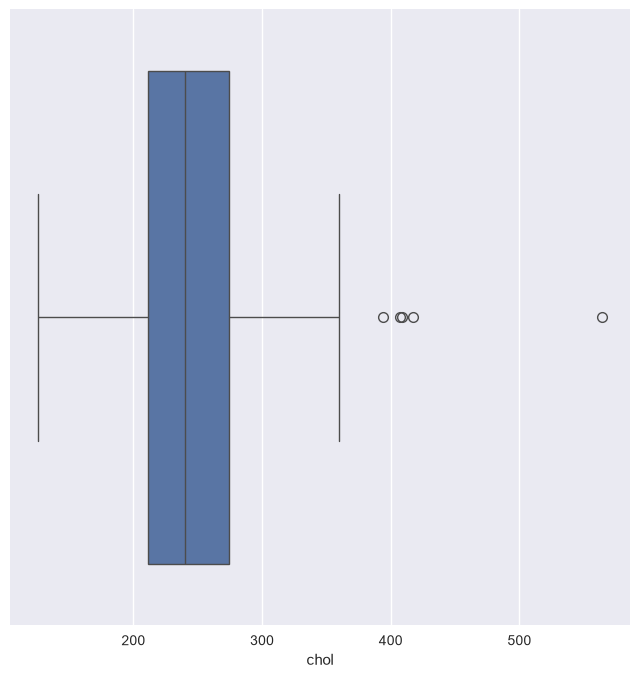

In [18]:

plt.figure(figsize = (8, 8))
sns.boxplot(data = data, x = 'chol')

<Axes: xlabel='trestbps'>

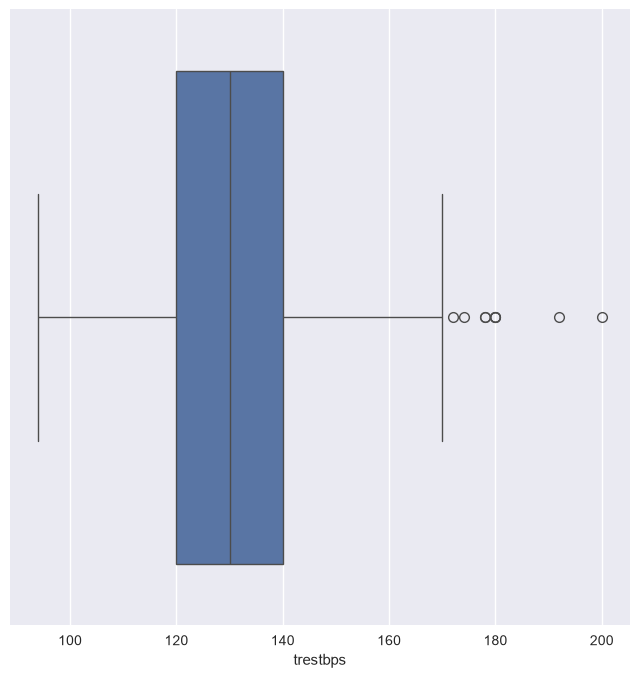

In [19]:
plt.figure(figsize = (8, 8))
sns.boxplot(data = data, x = 'trestbps')

Boxplot for feature 'Thalach'

<Axes: xlabel='thalach'>

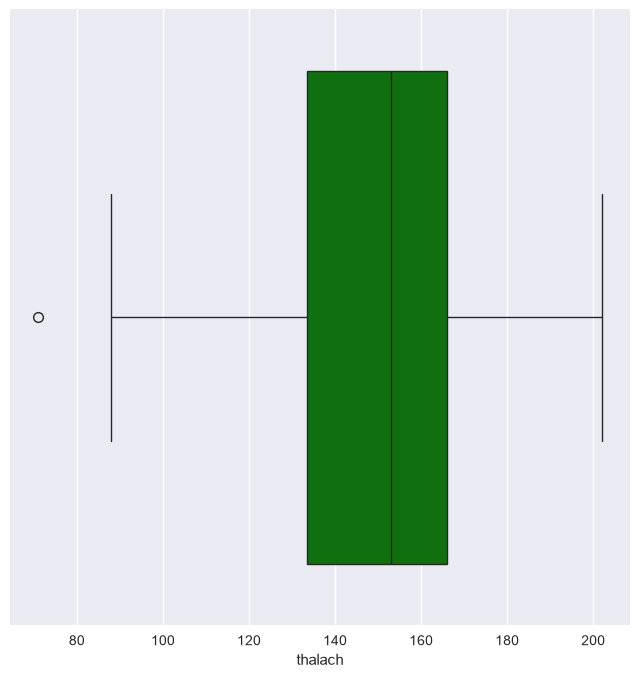

In [20]:

plt.figure(figsize = (8, 8))
sns.boxplot(data = data, x = 'thalach', color = 'green')


Boxplot for feature 'Age'

<Axes: ylabel='age'>

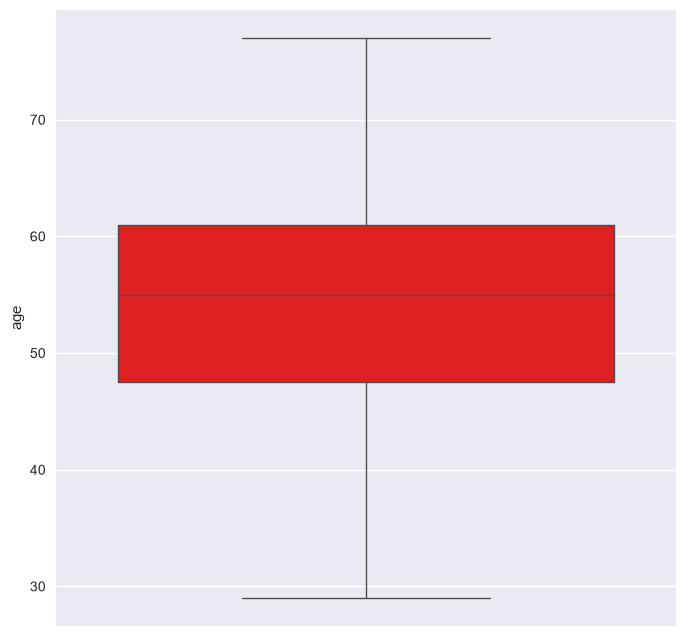

In [21]:

plt.figure(figsize = (8, 8))
sns.boxplot(data = data, y = 'age', color = 'red')


Assigning values from dataset

In [22]:

X = data.drop(['target'], axis = 1)
y = data['target']

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dividing data using train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

Getting the shape

In [25]:
X_train.shape

(227, 13)

In [26]:
X_test.shape

(76, 13)

Creating Empty Lists

In [27]:
# Store results and ROC data
metrics = []
roc_data = {}

In [28]:
# Function to evaluate and store model performance
def evaluate_model(name, model, X_test, y_test, y_pred, y_pred_prob):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)

    # Confusion matrix values (TP, TN, FP, FN)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total = tn + fp + fn + tp

    print(f"\n{name} Confusion Matrix:")
    print(f"Total - {total} | Positive (1) - {tp + fn} | Negative (0) - {tn + fp}")
    print(f"Positive (1) - {tp} TP | {fn} FN")
    print(f"Negative (0) - {fp} FP | {tn} TN")

    metrics.append([name, accuracy, precision, recall, f1, auc, tp, tn, fp, fn])

    roc_curve_data = roc_curve(y_test, y_pred_prob)
    roc_data[name] = (roc_curve_data, auc)


In [29]:
# 1. Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]
evaluate_model('Decision Tree', dt, X_test, y_test, y_pred_dt, y_pred_prob_dt)


Decision Tree Confusion Matrix:
Total - 76 | Positive (1) - 41 | Negative (0) - 35
Positive (1) - 33 TP | 8 FN
Negative (0) - 7 FP | 28 TN


In [30]:
# 2. Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest', rf, X_test, y_test, y_pred_rf, y_pred_prob_rf)


Random Forest Confusion Matrix:
Total - 76 | Positive (1) - 41 | Negative (0) - 35
Positive (1) - 35 TP | 6 FN
Negative (0) - 8 FP | 27 TN


In [31]:
# 3. Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_prob_lr = lr.predict_proba(X_test)[:, 1]
evaluate_model('Logistic Regression', lr, X_test, y_test, y_pred_lr, y_pred_prob_lr)


Logistic Regression Confusion Matrix:
Total - 76 | Positive (1) - 41 | Negative (0) - 35
Positive (1) - 38 TP | 3 FN
Negative (0) - 6 FP | 29 TN


C:\Users\rahul\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
# 4. K-Nearest Neighbors Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_pred_prob_knn = knn.predict_proba(X_test)[:, 1]
evaluate_model('K-Nearest Neighbors', knn, X_test, y_test, y_pred_knn, y_pred_prob_knn)


K-Nearest Neighbors Confusion Matrix:
Total - 76 | Positive (1) - 41 | Negative (0) - 35
Positive (1) - 31 TP | 10 FN
Negative (0) - 13 FP | 22 TN


In [33]:
# 5. Decision Tree with Grid Search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(3, 10),
    'min_samples_split': range(2, 10)
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_
y_pred_grid = best_dt.predict(X_test)
y_pred_prob_grid = best_dt.predict_proba(X_test)[:, 1]
evaluate_model('Decision Tree (Grid Search)', best_dt, X_test, y_test, y_pred_grid, y_pred_prob_grid)


Decision Tree (Grid Search) Confusion Matrix:
Total - 76 | Positive (1) - 41 | Negative (0) - 35
Positive (1) - 33 TP | 8 FN
Negative (0) - 6 FP | 29 TN


In [34]:
# Step 8: Create DataFrame for the results
metrics_df = pd.DataFrame(metrics, columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'TP', 'TN', 'FP', 'FN'])
print("\nPerformance Comparison Table (All Metrics with Confusion Matrix):")
print(metrics_df)


Performance Comparison Table (All Metrics with Confusion Matrix):
                     Algorithm  Accuracy  Precision    Recall  F1 Score  \
0                Decision Tree  0.802632   0.825000  0.804878  0.814815   
1                Random Forest  0.815789   0.813953  0.853659  0.833333   
2          Logistic Regression  0.881579   0.863636  0.926829  0.894118   
3          K-Nearest Neighbors  0.697368   0.704545  0.756098  0.729412   
4  Decision Tree (Grid Search)  0.815789   0.846154  0.804878  0.825000   

        AUC  TP  TN  FP  FN  
0  0.802439  33  28   7   8  
1  0.899303  35  27   8   6  
2  0.910801  38  29   6   3  
3  0.756794  31  22  13  10  
4  0.861324  33  29   6   8  


In [35]:
# Step 9: Performance Vector (summary metrics of accuracy, precision, recall, F1, AUC)
metrics_df['Performance Vector'] = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']].apply(lambda x: np.mean(x), axis=1)

In [36]:
# Display Performance Vector
print("\nPerformance Vector (Average of all key metrics):")
print(metrics_df[['Algorithm', 'Performance Vector']])


Performance Vector (Average of all key metrics):
                     Algorithm  Performance Vector
0                Decision Tree            0.809953
1                Random Forest            0.843208
2          Logistic Regression            0.895393
3          K-Nearest Neighbors            0.728844
4  Decision Tree (Grid Search)            0.830629


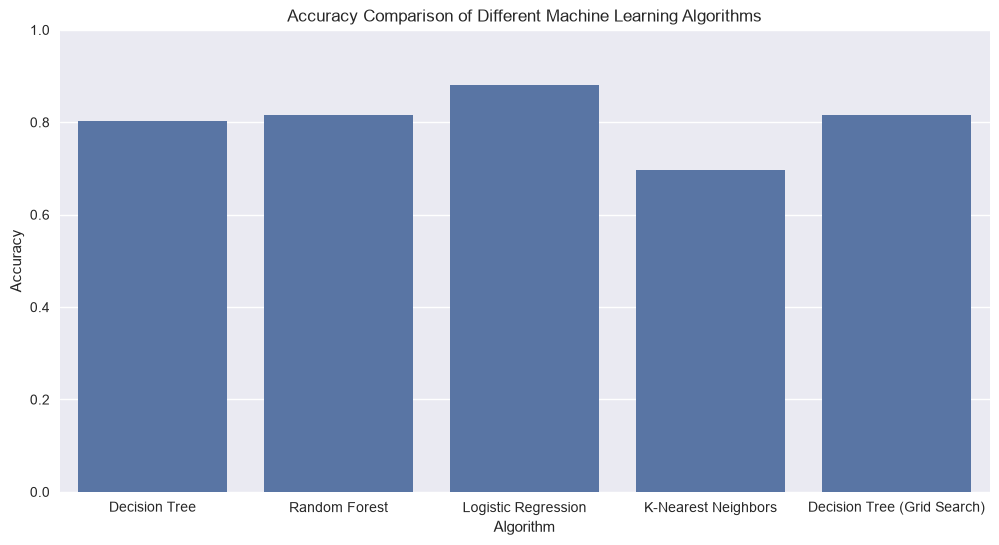

In [37]:
# Step 10: Plot comparison table using bar plot for Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(x='Algorithm', y='Accuracy', data=metrics_df)
plt.title('Accuracy Comparison of Different Machine Learning Algorithms')
plt.ylabel('Accuracy')
plt.xlabel('Algorithm')
plt.ylim(0, 1)
plt.show()

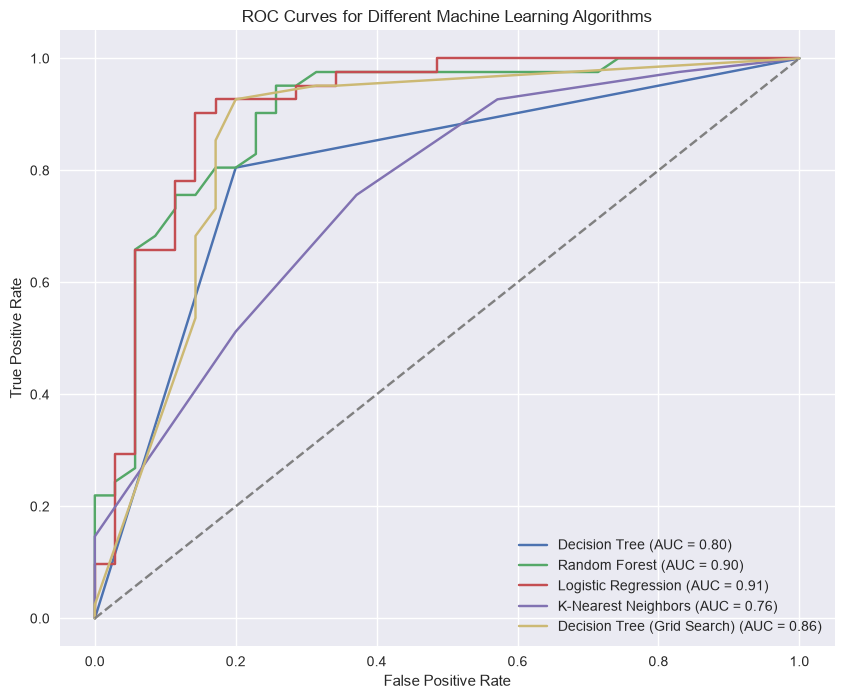

In [38]:
# Step 11: Plotting ROC curves for comparison
plt.figure(figsize=(10, 8))
for model, (roc_curve_data, auc_score) in roc_data.items():
    fpr, tpr, _ = roc_curve_data
    plt.plot(fpr, tpr, label=f'{model} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line
plt.title('ROC Curves for Different Machine Learning Algorithms')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [39]:
# Step 12: Feature Importance for Random Forest
importances = rf.feature_importances_  # Extract feature importances from the model
feature_names = data.drop(columns=['target']).columns  # Feature names excluding the target column
sorted_indices = np.argsort(importances)[::-1]  # Sorting the feature importance in descending order

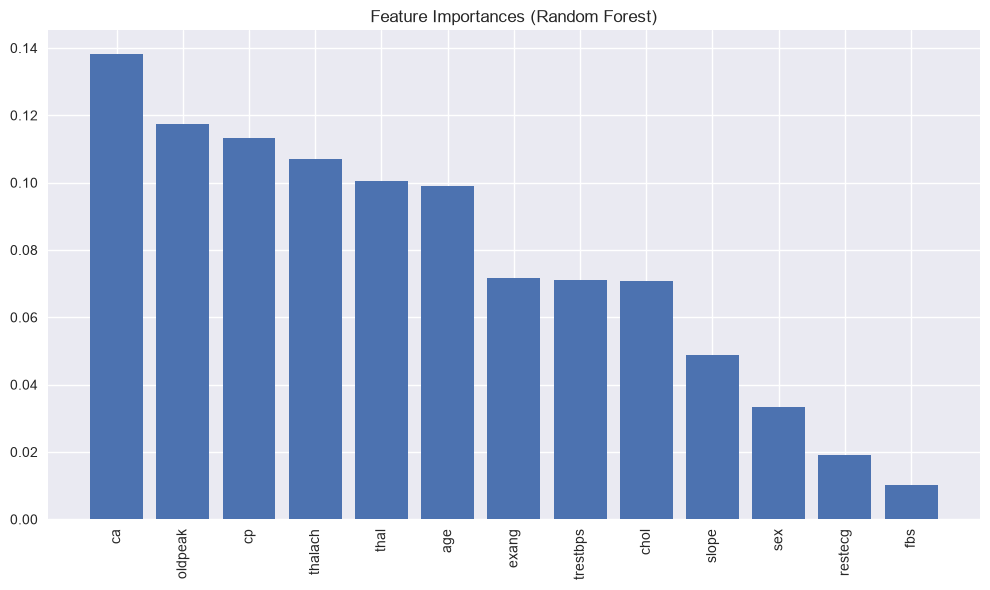

In [40]:
# Plotting the feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[sorted_indices], rotation=90)  # Rotate feature names for readability
plt.tight_layout()
plt.show()

Feature Importance Table:
 Rank  Feature  Importance
    1       ca    0.138289
    2  oldpeak    0.117503
    3       cp    0.113270
    4  thalach    0.107002
    5     thal    0.100357
    6      age    0.098948
    7    exang    0.071555
    8 trestbps    0.071100
    9     chol    0.070658
   10    slope    0.048754
   11      sex    0.033463
   12  restecg    0.018989
   13      fbs    0.010111


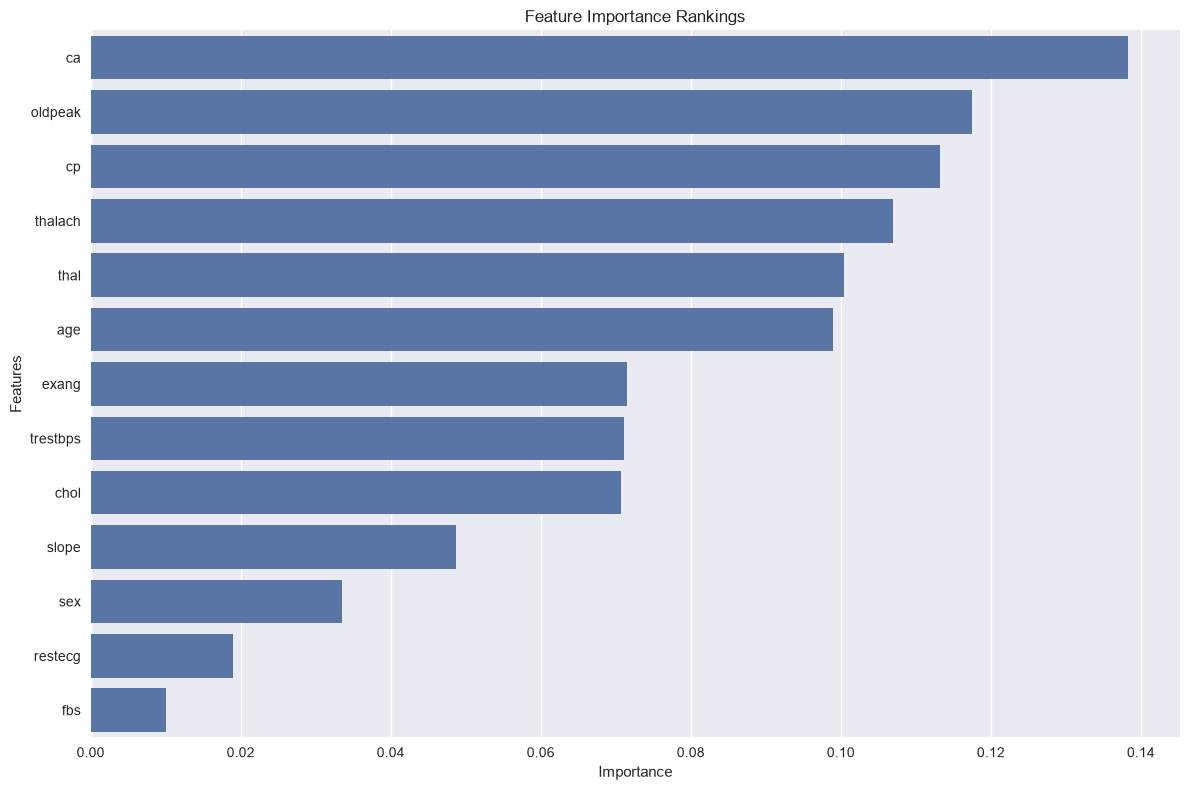

In [41]:
importances = rf.feature_importances_
feature_names = X.columns

# Create a dataframe of feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the dataframe by importance in descending order
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Add a rank column
feature_importance_df['Rank'] = feature_importance_df.index + 1

# Reorder columns
feature_importance_df = feature_importance_df[['Rank', 'Feature', 'Importance']]

# Display the table
print("Feature Importance Table:")
print(feature_importance_df.to_string(index=False))

# Optionally, save to CSV
# feature_importance_df.to_csv('feature_importance.csv', index=False)

# Create a bar plot of feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance Rankings')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

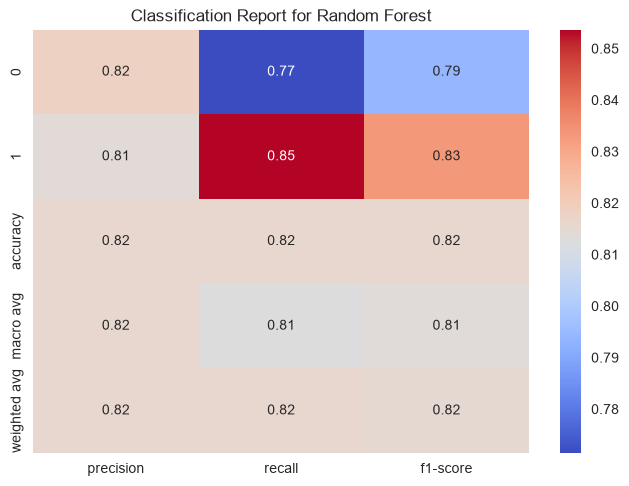

In [42]:

# Step 13: Classification Report Visualization (heatmap)
# Visualize the precision, recall, and F1-score for Random Forest
clf_report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
sns.heatmap(pd.DataFrame(clf_report_rf).iloc[:-1, :].T, annot=True, cmap="coolwarm")
plt.title("Classification Report for Random Forest")
plt.show()

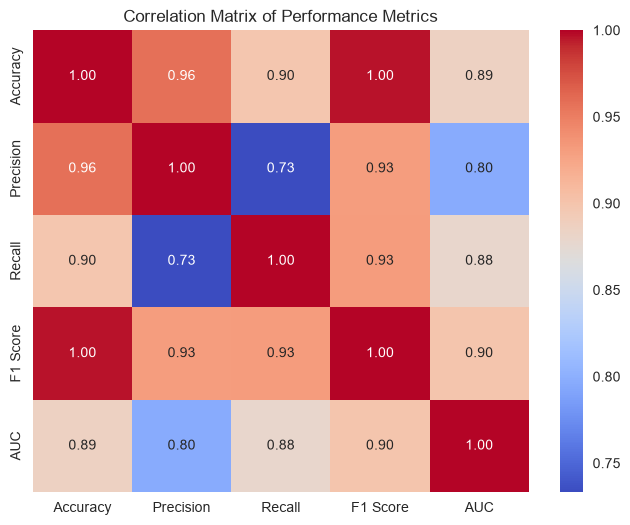

In [43]:
# Step 15: Correlation Matrix of Performance Metrics
metrics_correlation = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(metrics_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Performance Metrics')
plt.show()


Final Accuracy Comparison Table for All Algorithms:
                     Algorithm  Accuracy
0                Decision Tree  0.802632
1                Random Forest  0.815789
2          Logistic Regression  0.881579
3          K-Nearest Neighbors  0.697368
4  Decision Tree (Grid Search)  0.815789


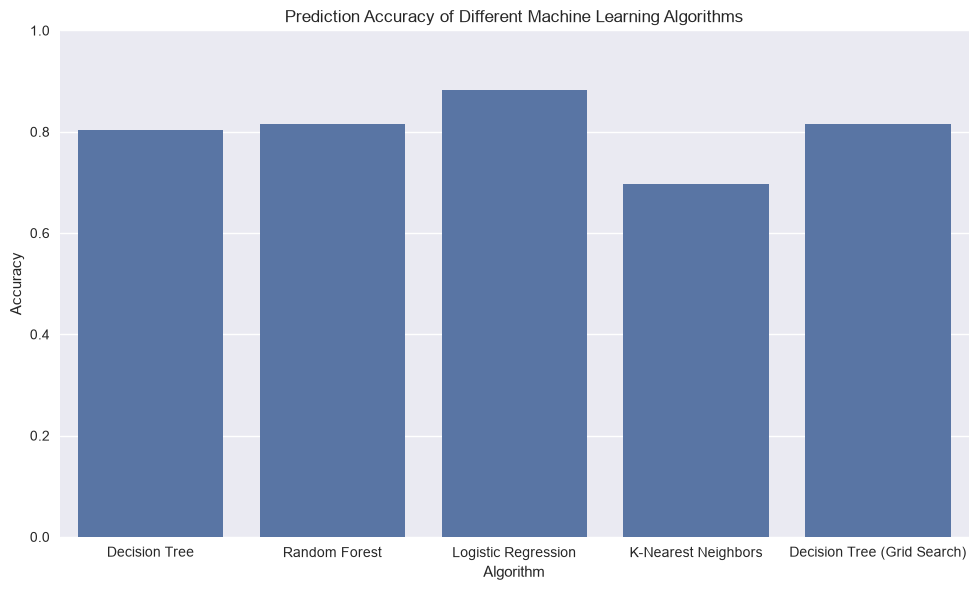

In [44]:
# Final Comparison Table for Prediction Accuracy of all Algorithms
print("\nFinal Accuracy Comparison Table for All Algorithms:")
accuracy_comparison = metrics_df[['Algorithm', 'Accuracy']]
print(accuracy_comparison)

# Plotting Accuracy Comparison for better visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Accuracy', data=accuracy_comparison)
plt.title('Prediction Accuracy of Different Machine Learning Algorithms')
plt.ylabel('Accuracy')
plt.xlabel('Algorithm')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [45]:
import pickle

## Step 17: Create DataFrame for the results
metrics_df = pd.DataFrame(metrics, columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'TP', 'TN', 'FP', 'FN'])
print("\nPerformance Comparison Table (All Metrics with Confusion Matrix):")
print(metrics_df)


Performance Comparison Table (All Metrics with Confusion Matrix):
                     Algorithm  Accuracy  Precision    Recall  F1 Score  \
0                Decision Tree  0.802632   0.825000  0.804878  0.814815   
1                Random Forest  0.815789   0.813953  0.853659  0.833333   
2          Logistic Regression  0.881579   0.863636  0.926829  0.894118   
3          K-Nearest Neighbors  0.697368   0.704545  0.756098  0.729412   
4  Decision Tree (Grid Search)  0.815789   0.846154  0.804878  0.825000   

        AUC  TP  TN  FP  FN  
0  0.802439  33  28   7   8  
1  0.899303  35  27   8   6  
2  0.910801  38  29   6   3  
3  0.756794  31  22  13  10  
4  0.861324  33  29   6   8  


In [46]:
# Step 18: Performance Vector (summary metrics of accuracy, precision, recall, F1, AUC)
metrics_df['Performance Vector'] = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']].apply(lambda x: np.mean(x), axis=1)


In [47]:
# Display Performance Vector
print("\nPerformance Vector (Average of all key metrics):")
print(metrics_df[['Algorithm', 'Performance Vector']])


Performance Vector (Average of all key metrics):
                     Algorithm  Performance Vector
0                Decision Tree            0.809953
1                Random Forest            0.843208
2          Logistic Regression            0.895393
3          K-Nearest Neighbors            0.728844
4  Decision Tree (Grid Search)            0.830629


In [48]:
# Step 19: Automatically select the model with the highest accuracy
best_model_name = metrics_df.loc[metrics_df['Accuracy'].idxmax(), 'Algorithm']
print(f"\nBest Model Based on Accuracy: {best_model_name}")


Best Model Based on Accuracy: Logistic Regression


In [49]:

# Select the corresponding trained model based on the name
if best_model_name == 'Decision Tree':
    best_model = dt
elif best_model_name == 'Random Forest':
    best_model = rf
elif best_model_name == 'Logistic Regression':
    best_model = lr
elif best_model_name == 'K-Nearest Neighbors':
    best_model = knn
elif best_model_name == 'Decision Tree (Grid Search)':
    best_model = best_dt

In [50]:
# Save the best model into a pickle file
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Best model saved as 'best_model.pkl' for deployment.")

Best model saved as 'best_model.pkl' for deployment.


In [51]:
predictions = best_model.predict(X_test)

In [52]:
predicted_classes = (predictions > 0.5).astype(int)

In [53]:
results_df = pd.DataFrame({
    'Actual': y_test,               # True labels
    'Predicted': predicted_classes.flatten()  # Predicted labels
})

In [54]:
print("Predictions Results:")
display(results_df)

Predictions Results:


,Actual,Predicted
179,0,0
228,0,1
111,1,1
246,0,0
60,1,1
...,...,...
22,1,1
258,0,1
56,1,1
242,0,0


In [55]:
results_df.head()

,Actual,Predicted
179,0,0
228,0,1
111,1,1
246,0,0
60,1,1


In [56]:
results_df.tail()

,Actual,Predicted
22,1,1
258,0,1
56,1,1
242,0,0
114,1,1


In [57]:
cm = confusion_matrix(y_test, predicted_classes)
cm_df = pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], 
                     columns=['Predicted Negative', 'Predicted Positive'])

In [58]:
cm_df

,Predicted Negative,Predicted Positive
Actual Negative,29,6
Actual Positive,3,38


In [59]:
model = RandomForestClassifier()

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

In [60]:
# Set up Grid Search with cross-validation
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

In [61]:
# Fit the model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gri

In [62]:
# Best parameters from Grid Search
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [63]:
# Evaluate the model with cross-validation
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross-Validation Scores: [0.82608696 0.80434783 0.8        0.8        0.75555556]
Mean CV Score: 0.7971980676328503


In [64]:
# Make predictions on the test set
y_pred = grid_search.predict(X_test)

In [65]:
# Evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[29  6]
 [ 5 36]]
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        35
           1       0.86      0.88      0.87        41

    accuracy                           0.86        76
   macro avg       0.86      0.85      0.85        76
weighted avg       0.86      0.86      0.86        76

